# Retention AI Lab - EDA & Model Training
## Imports

In [159]:
import pandas as pds
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import math
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder


## fix path & load data

In [ ]:
curr_dir = Path.cwd()
file_path = f"{curr_dir}/data/df_RetentionAI.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Fichier introuvable : {os.path.abspath(file_path)}")

# load data
df_init=pds.read_csv(file_path)
df_init.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Statistics

In [ ]:
print("=== Info ===")
df_info=df_init.info()

=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-nul

## Unique values
### Num

In [131]:
df_numb=df_init.select_dtypes(include=np.number)
for col_num in df_numb:    
    unique_val_num=df_numb[col_num].nunique()       
    print(f"{col_num} ==> {unique_val_num}")

Age ==> 43
DailyRate ==> 886
DistanceFromHome ==> 29
Education ==> 5
EmployeeCount ==> 1
EmployeeNumber ==> 1470
EnvironmentSatisfaction ==> 4
HourlyRate ==> 71
JobInvolvement ==> 4
JobLevel ==> 5
JobSatisfaction ==> 4
MonthlyIncome ==> 1349
MonthlyRate ==> 1427
NumCompaniesWorked ==> 10
PercentSalaryHike ==> 15
PerformanceRating ==> 2
RelationshipSatisfaction ==> 4
StandardHours ==> 1
StockOptionLevel ==> 4
TotalWorkingYears ==> 40
TrainingTimesLastYear ==> 7
WorkLifeBalance ==> 4
YearsAtCompany ==> 37
YearsInCurrentRole ==> 19
YearsSinceLastPromotion ==> 16
YearsWithCurrManager ==> 18


### str

In [122]:
df_object=df_init.select_dtypes(['object'])
for cols_obj in df_object:
        # print(f"{cols_obj} => {df_object[cols_obj].nunique()}")
        unique_obj=df_object[cols_obj].nunique()
        print(f"{cols_obj} => {unique_obj}")

Attrition => 2
BusinessTravel => 3
Department => 3
EducationField => 6
Gender => 2
JobRole => 9
MaritalStatus => 3
Over18 => 1
OverTime => 2


In [128]:
print("=== Shape ===")
print(df_init.shape)

print("=== Description ===")
df_init.describe()

=== Shape ===
(1470, 35)
=== Description ===


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [83]:
df_init.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [87]:
df_cols=['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']

## Minimal Univariate Analysis

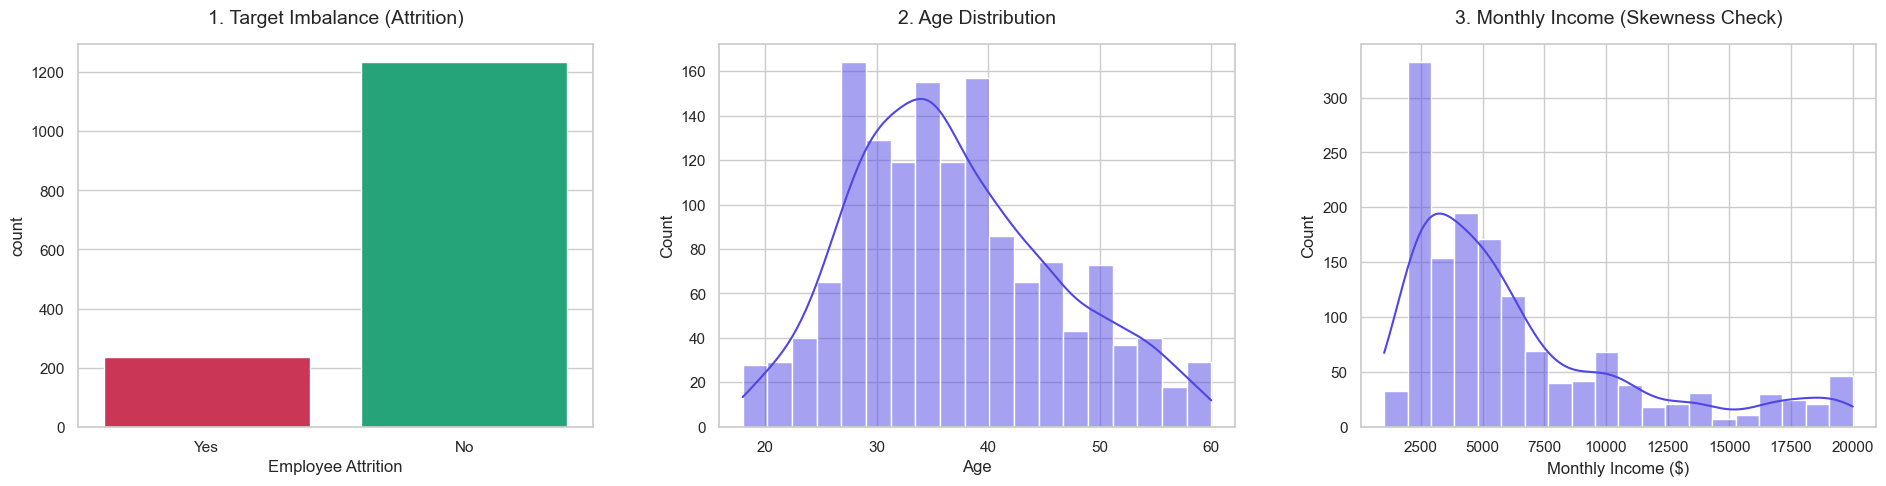

In [ ]:
# visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 6))

# ---  1: Target Variable ---
plt.subplot(1, 3, 1)
sns.countplot(data=df_init, x='Attrition', palette={'Yes': '#e11d48', 'No': '#10b981'})
plt.title("1. Target Imbalance (Attrition)", fontsize=14, pad=15)
plt.xlabel("Employee Attrition", fontsize=12)

# --- 2: Age Distribution ---
plt.subplot(1, 3, 2)
sns.histplot(data=df_init, x='Age', kde=True, color='#4f46e5')
plt.title("2. Age Distribution", fontsize=14, pad=15)
plt.xlabel("Age", fontsize=12)

# --- 3: Monthly Income Distribution ---
plt.subplot(1, 3, 3)
sns.histplot(data=df_init, x='MonthlyIncome', kde=True, color='#4f46e5')
plt.title("3. Monthly Income (Skewness Check)", fontsize=14, pad=15)  # skewness <=> asymetrie 
plt.xlabel("Monthly Income ($)", fontsize=12)

# padding -> no overlaps
plt.tight_layout(pad=4.0)
plt.show()

## Bivariate Analysis  
### str cols vs Attrition

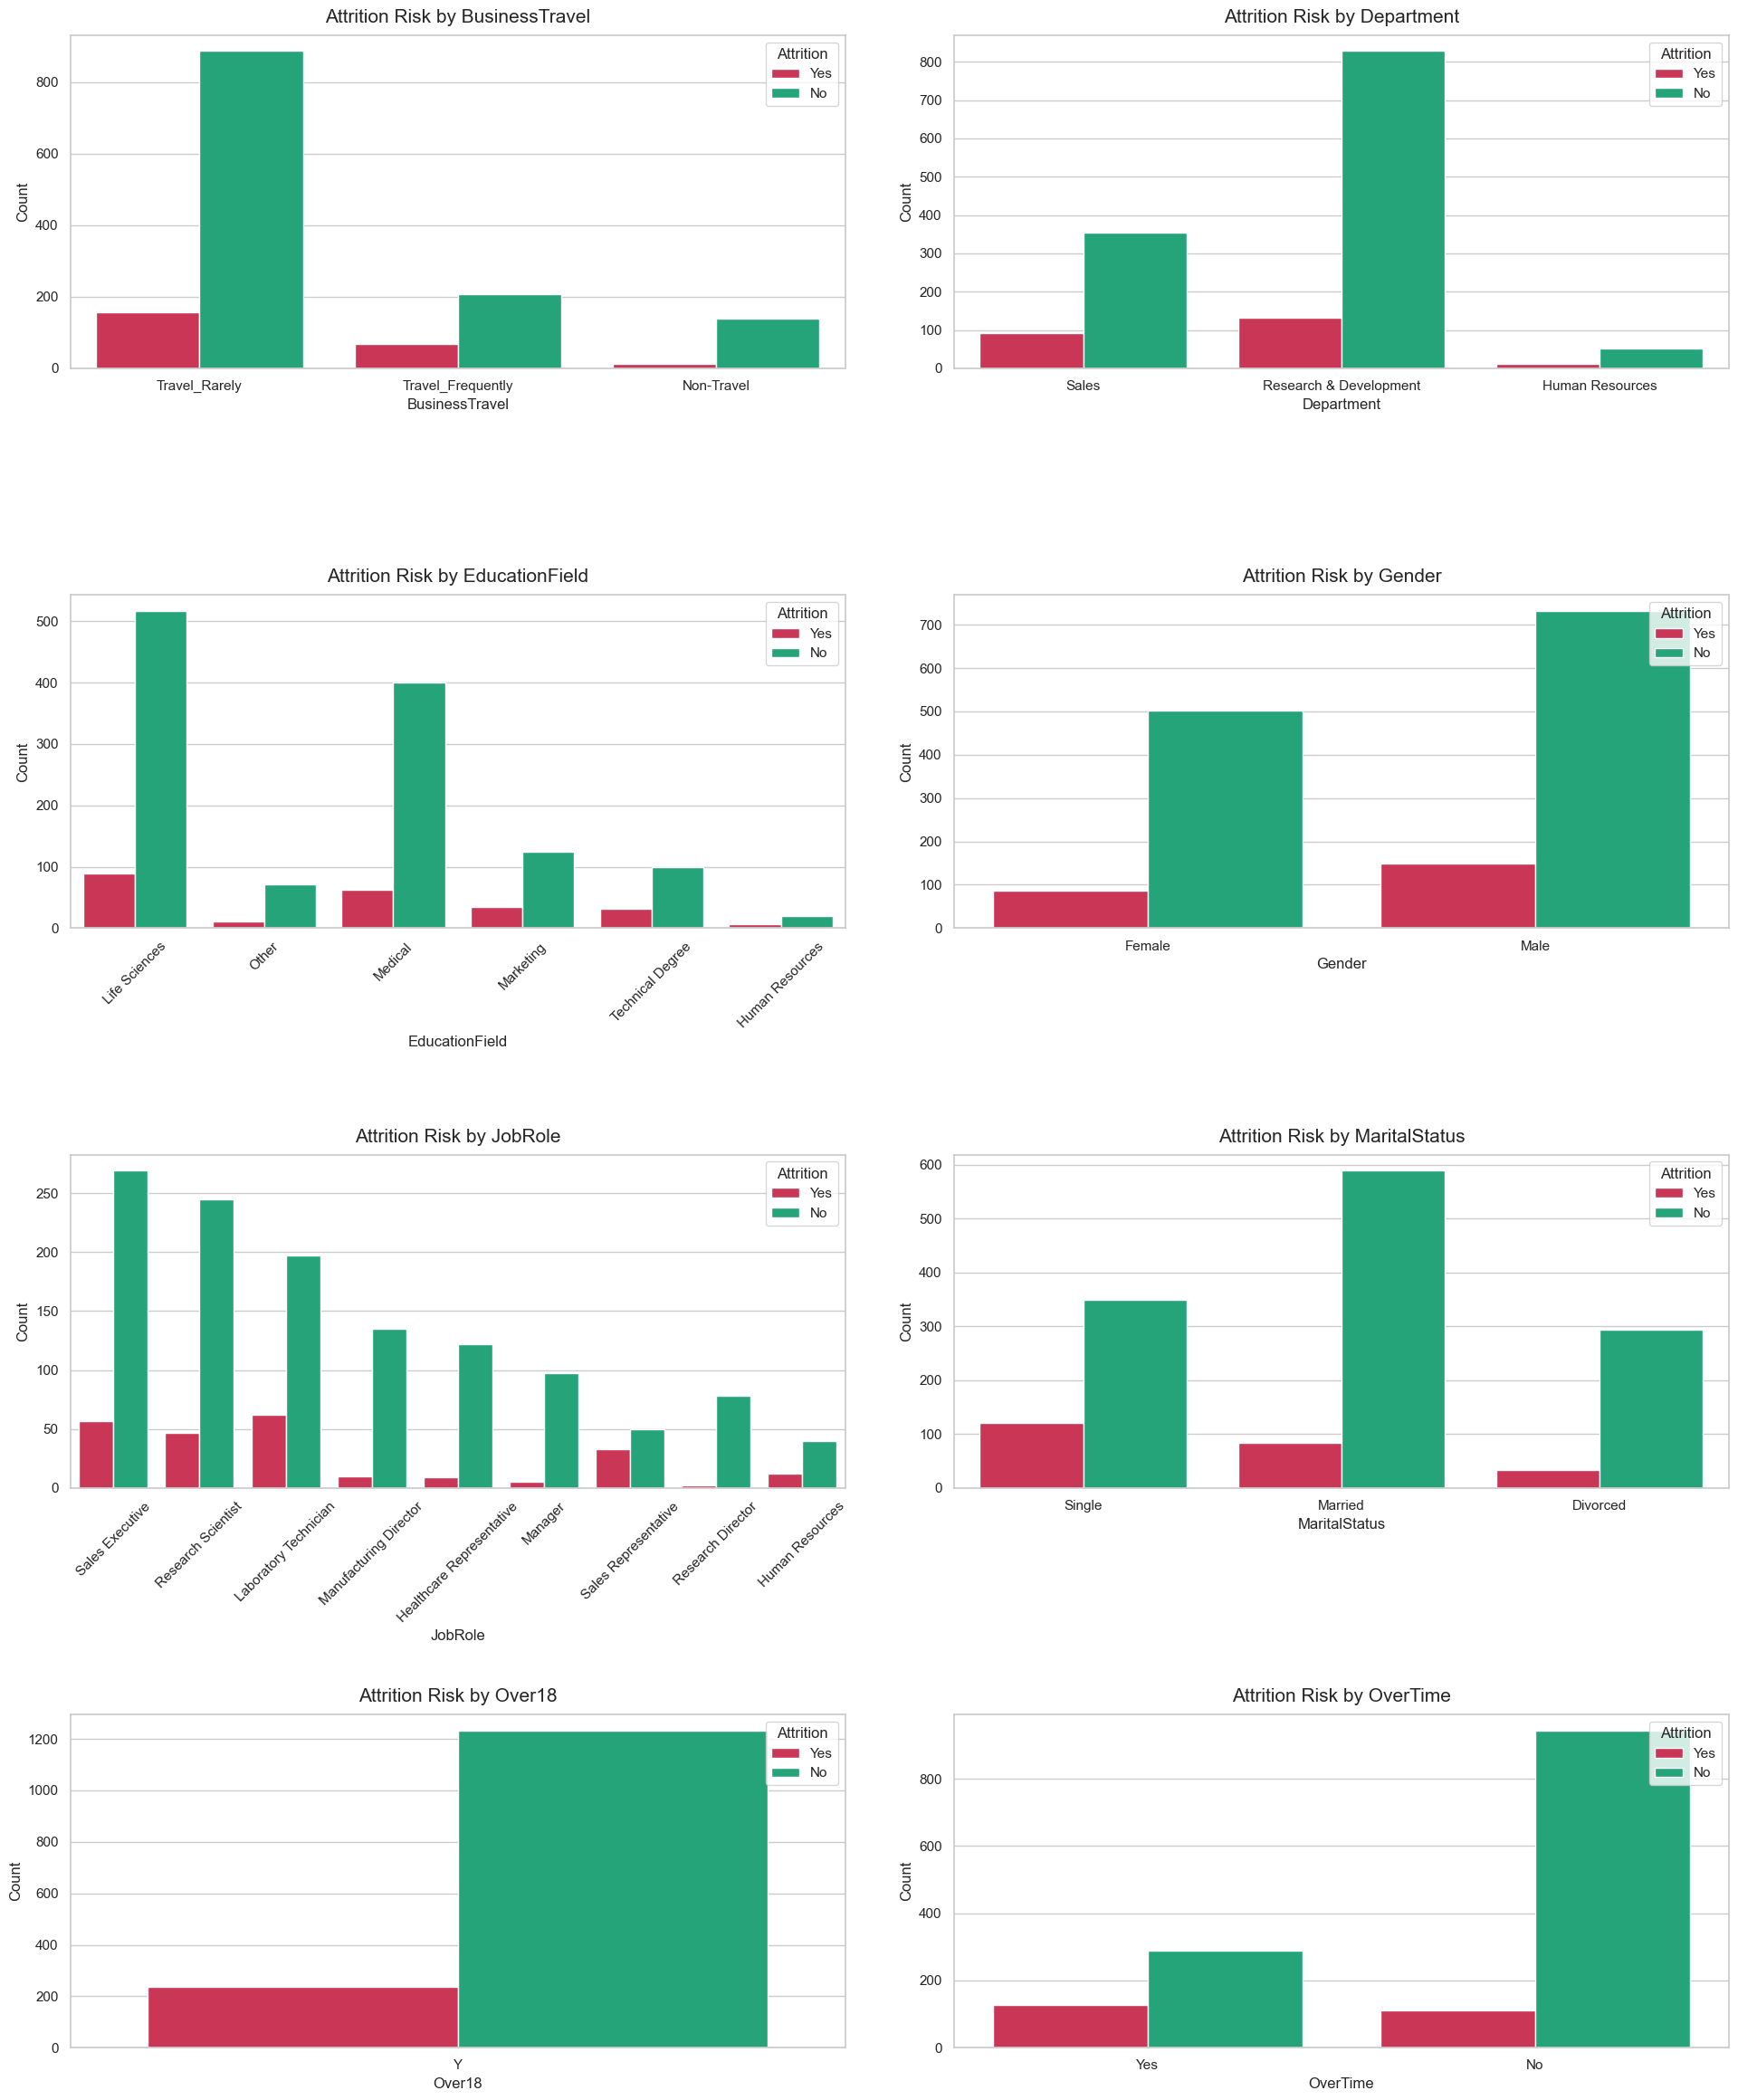

In [ ]:
# --- select str cols
df_obj = df_init.select_dtypes(include='object').columns.tolist()

# Remove Attrition from the list 
if 'Attrition' in df_obj:
    df_obj.remove('Attrition')

# Calculate the num of rows needed for a grid with 2 cols
n_cols = 2
n_rows = math.ceil(len(df_obj) / n_cols)

# Create the fig
plt.figure(figsize=(20, n_rows * 6)) # Dynamic height based on num of rows

for i, col in enumerate(df_obj):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # G => No | R => Yes
    sns.countplot(data=df_init, x=col, hue='Attrition', palette={'Yes': '#e11d48', 'No': '#10b981'})
    
    plt.title(f"Attrition Risk by {col}", fontsize=15, pad=10)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Count")
    plt.legend(title='Attrition', loc='upper right')
    
    # many categories => Rotate labels (like JobRole or EducationField)
    if df_init[col].nunique() > 3:
        plt.xticks(rotation=45)

# => no overlap
plt.tight_layout(pad=3.0)
plt.show()

### Numeric Categorical vs Attrition


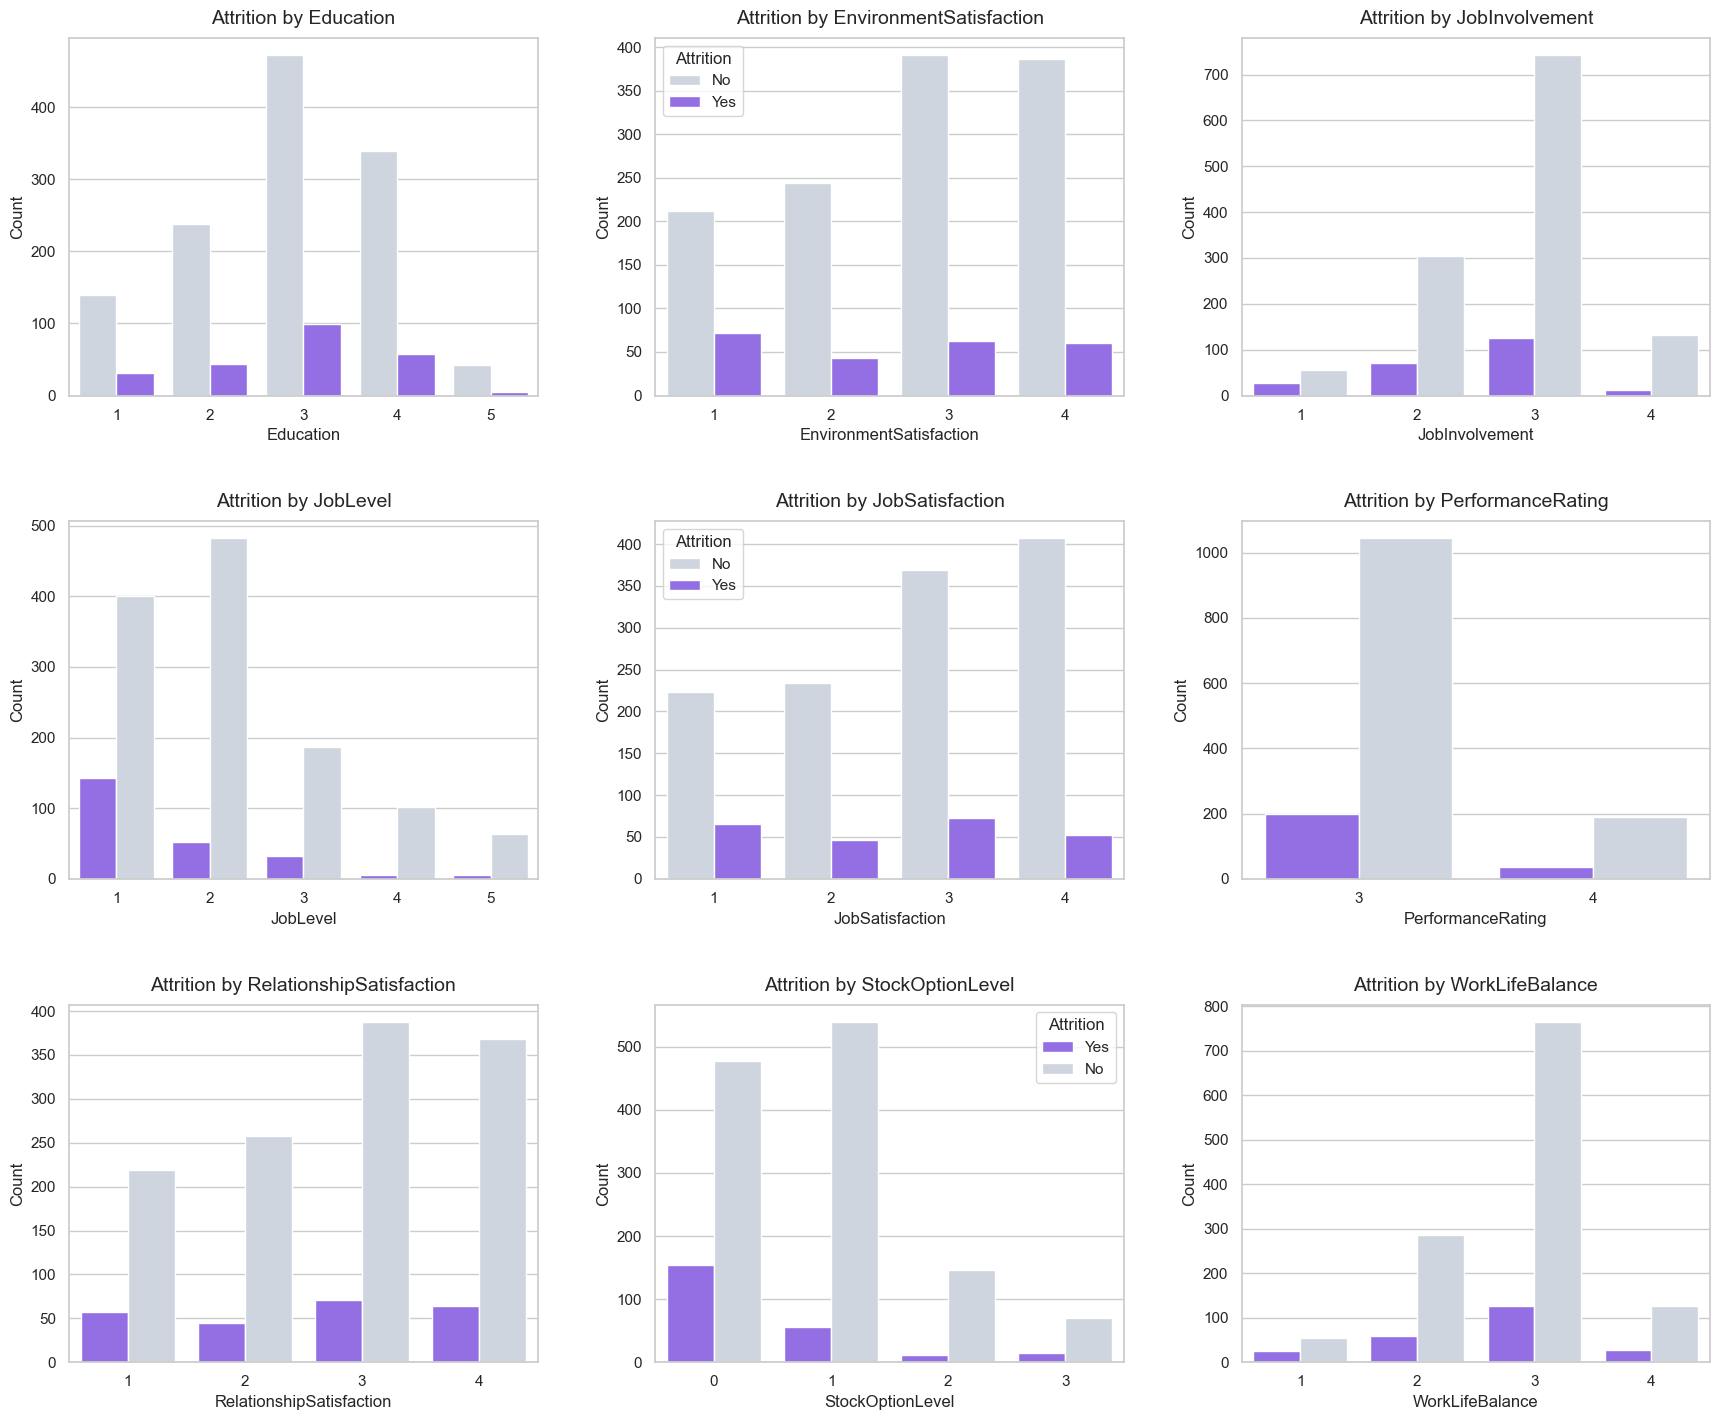

In [133]:
# cols that are already encoded from str to num 
ordinal_columns = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 
    'JobLevel', 'JobSatisfaction', 'PerformanceRating', 
    'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance'
]

# --- dynamic grid (3 columns wide)
n_cols = 3
n_rows = math.ceil(len(ordinal_columns) / n_cols)

# fig 
plt.figure(figsize=(18, n_rows * 5)) 

# 1 column -> 1 countplot 
for i, col in enumerate(ordinal_columns):
    # Select the correct subplot
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.countplot(data=df_init, x=col, hue='Attrition', palette={'Yes': '#8b5cf6', 'No': '#cbd5e1'})
    
    plt.title(f"Attrition by {col}", fontsize=14, pad=10)
    plt.xlabel(f"{col}", fontsize=12)
    plt.ylabel("Count")
    
    #  clutterst : legend on the 1st chart 
    legend=[1,4,7]

    if i in legend:
    # if i==0:
        plt.legend(title='Attrition')
    else:
        plt.legend([],[], frameon=False) 

# Adjust layout & hide any empty subplots automatically
plt.tight_layout(pad=3.0)
plt.show()

## Correlation
### Encoding Traget Variable - mapping


In [138]:
# -- Isolate nume cols
df_num = df_init.select_dtypes(exclude='object').copy()

# --- Map() 
df_num['Attrition_Binary'] = df_init['Attrition'].map({'Yes': 1, 'No': 0})
df_num['Attrition_Binary'].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition_Binary, dtype: int64

### Bar Chart - Features vs. Target 

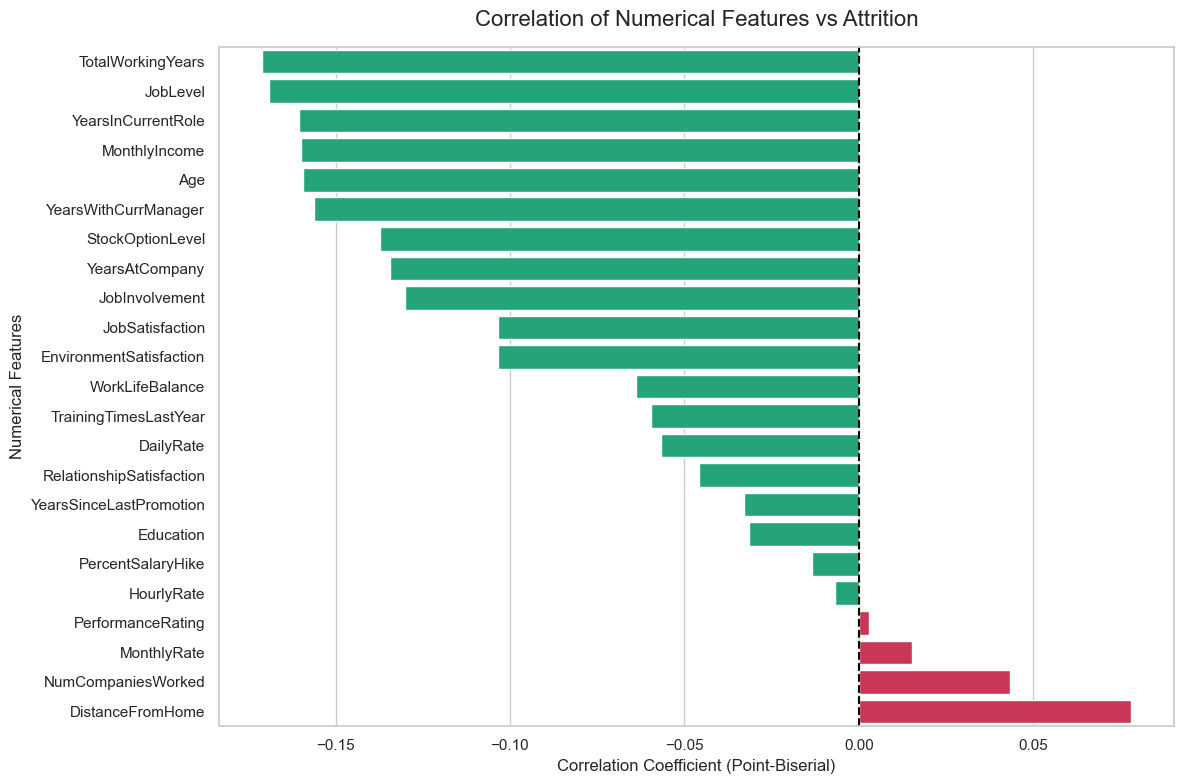

In [111]:
# 1. Isolate numerical columns and DROP the useless ones
useless_cols = ['EmployeeCount', 'StandardHours', 'EmployeeNumber']
df_num = df_init.select_dtypes(exclude='object').drop(
    columns=[c for c in useless_cols if c in df_init.columns]
)

# Map()
df_num['Attrition_Binary'] = df_init['Attrition'].map({'Yes': 1, 'No': 0})

# 3. Calculate correlations with the target
correlations = df_num.corr()['Attrition_Binary'].drop('Attrition_Binary').sort_values()

# 4. Plot the correlations
plt.figure(figsize=(12, 8))

# G (-) & R (+)
colors = ['#10b981' if c < 0 else '#e11d48' for c in correlations] 

sns.barplot(x=correlations.values, y=correlations.index, palette=colors)

plt.title("Correlation of Numerical Features vs Attrition", fontsize=16, pad=15)
plt.xlabel("Correlation Coefficient (Point-Biserial)", fontsize=12)
plt.ylabel("Numerical Features", fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # center line for reference

plt.tight_layout()
plt.show()

### Heatmap - Multicollinearity Check

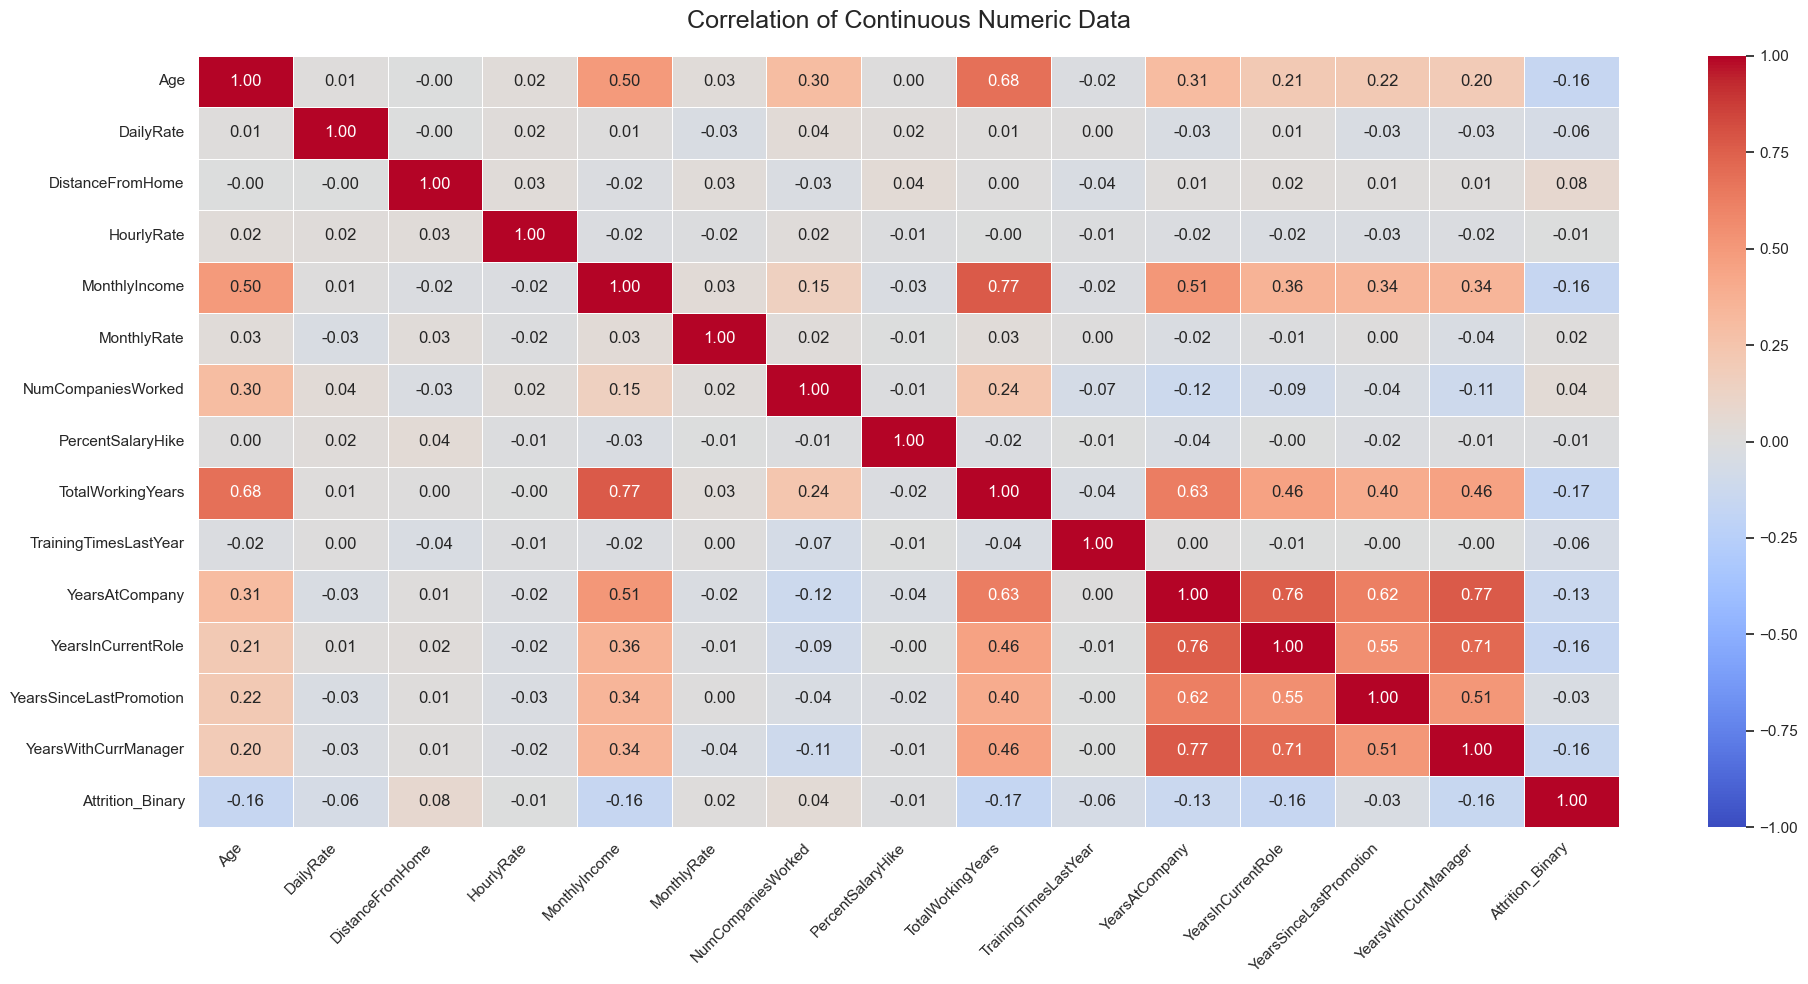

In [139]:
# --- cols to drop for heatmap 
cols_to_drop_for_corr = [
    'EmployeeCount', 'StandardHours', 'EmployeeNumber',       # Useless/ID
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', # Ordinal
    'JobLevel', 'JobSatisfaction', 'PerformanceRating', 
    'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance'
]

# --- Isolate true continuous num cols
df_copy=df_init.copy() 
df_continuous = df_copy.select_dtypes(exclude='object').drop(
    columns=[c for c in cols_to_drop_for_corr if c in df_init.columns]
)
df_continuous_1=pds.concat([df_continuous,df_num['Attrition_Binary']],axis=1)

# --- Calculate correlation 
corr_matrix = df_continuous_1.corr()

# --- mask : upper triangle 
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# --- Plot the Heatmap
plt.figure(figsize=(20, 10))

sns.heatmap(
    corr_matrix, 
    # mask=mask, 
    annot=True, fmt=".2f",             
    cmap="coolwarm",       # Blue - , Red + 
    vmin=-1.0, vmax=1.0,   # standard mathematical scale
    linewidths=0.5         # gridlines between the squares
) 

plt.title("Correlation of Continuous Numeric Data", fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

## Cleaning Process


### Missing Values

In [ ]:
# there is no miss val in this datasets
print("___ Missing Values ___")
for col_num in df_init:
    miss_cpt=df_init.isnull().sum()
    miss_val= miss_cpt[miss_cpt > 0]
    # print("0 missing values") if miss_val.empty else print(miss_val)

___ Missing Values ___


### Duplicate Rows

In [124]:
df_init.duplicated().sum()

np.int64(0)

### Drop Useless Columns

In [ ]:
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber', 'JobLevel']
df_copy=df_init.copy()
df_cleaned = df_copy.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"before dropping: {df_init.shape}")  
print(f"New dataset shape: {df_cleaned.shape}")

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber', 'JobLevel']
before dropping: (1470, 35)
New dataset shape: (1470, 30)


### Encoding  

In [140]:
df_obj_copy=df_copy.select_dtypes(['object'])

### Relational - LabelEncoder  

In [162]:
list_relation = ["BusinessTravel", "OverTime", "Gender"]
print(" === Relational === ")
oe = OrdinalEncoder()
r_encoded = oe.fit_transform(df_obj_copy[list_relation])
print(r_encoded)

 === Relational === 
[[2. 1. 0.]
 [1. 0. 1.]
 [2. 1. 1.]
 ...
 [2. 1. 1.]
 [1. 0. 1.]
 [2. 0. 1.]]


### Non-Relational - One Hot Encoding

In [163]:
list_n_relation = ["Department", "EducationField", "JobRole", "MaritalStatus"]
print("\n === Non-Relational === ")
ohe = OneHotEncoder(sparse_output=False) 
nr_encoded = ohe.fit_transform(df_obj_copy[list_n_relation])
print(nr_encoded)


 === Non-Relational === 
[[0. 0. 1. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 1.]
 ...
 [0. 1. 0. ... 0. 1. 0.]
 [0. 0. 1. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 1. 0.]]


In [156]:
df_encoded_obj=pds.concat([
  pds.DataFrame(r_encoded, columns=['Attrition_Binary']), 
  pds.DataFrame(nr_encoded.toarray(), columns=ohe.get_feature_names_out())
  ], axis=1)
df_encoded_obj.head()

,Attrition_Binary,Attrition_No,Attrition_Yes,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


### Ultra Cleaning data

In [8]:
# --- objet
def clean_obj_ultra():
    global df_obj_cleaned
    df_obj_cleaned=df_obj.copy()
    cols_drop=['Attrition','Gender','Over18']
    df_obj_cleaned=df_obj_cleaned.drop(columns=cols_drop, axis=1, inplace=True)
    # df_obj_cleaned_ultra=pds.concat([df_encoded_obj, df_obj_cleaned], axis=1)
    return df_obj_cleaned

df_obj_cleaned_ultra=clean_obj_ultra()

# --- Num
""" def ultra_cleaning_num():
    ultra_cols=['EmployeeCount', 'StandardHours', 'Education', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance' ]
    df_corr_cleaned.drop(columns=ultra_cols, axis=1, inplace=True)
    return df_corr_cleaned """

# df_corr_cleaned_ultra=ultra_cleaning_num()

# --- cleaned datafile : Obj & Num
def clean_whole_data():
    df_cleaned=pds.concat([df_corr_cleaned, df_obj_cleaned_ultra],axis=1)
    return df_cleaned
    
print(clean_whole_data().columns)
df_final  = clean_whole_data()
    

Index(['Education', 'EmployeeCount', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'WorkLifeBalance'],
      dtype='object')


## Training Model
### Split Data

In [ ]:
print("___Attrition Before Encoding___")
print(data_file['Attrition'].unique() )

print("___Attrition After Encoding___")
encoded_target=encode_target()
print(encoded_target.unique() )

___Attrition Before Encoding___
['Yes' 'No']
___Attrition After Encoding___
[1 0]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# --- spliting data
df_final=clean_whole_data()
X=df_final
X=pds.get_dummies(df_final, drop_first=True)

encoded_target=encode_target()
y=encoded_target

X_train, X_test, y_train, y_test=train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=45, 
    stratify=y)

# --- Standarisation
scaler_var = StandardScaler()
scaler_var.fit(X_train)

X_train_scaled=scaler_var.transform(X_train)
X_test_scaled=scaler_var.transform(X_test)

# -> save scaler
path_scaler_var =f"../../models/scaler_attrition.pkl"
joblib.dump(scaler_var, path_scaler_var)

print("Sauvegarde terminé!")
# --- training data
# cerveau --> apprentisaseg --> examen --> resultat

# -> Cerveau
# _Choix du modele : conditional
""" print("1: Logistic Regression")
print("2: Random Forest Classifier")
choix=input("Choisissez le nombre du modele à implementer : ")
if choix == "1":
    model = LogisticRegression(random_state=45)
elif choix =="2":
    model = RandomForestClassifier(n_estimators=100, random_state=100)
 """

# loop :
model_dict={
    "RandomForestClassifier" : RandomForestClassifier(n_estimators=100, random_state=45),
    "LogisticRegression" : LogisticRegression(random_state=45)
}

for name, model_instance in model_dict.items():

# -> Apprentissage
    model_instance.fit(X_train_scaled, y_train)

# -> Examen
    y_pred=model_instance.predict(X_test_scaled)

# -> Resultats
    print(f" --- Resultats {name} --- ")
    print(f"Score Globale (Accuracy) : {accuracy_score(y_test, y_pred): .2%} ")

    print("-------------------- Details par classe -------------------- ")
    print("-------------------- Yes : 1, No : 0 -------------------- ")
    print(classification_report(y_test, y_pred))
    print("____________________________________________________________")
    print("\n")
# --- saving model
# -> save model
    path_model = f"../../models/{name}_model.pkl"
    
    joblib.dump(model_instance, path_model)

    print(f"Model sauvegardé dans : {path_model}")




Sauvegarde terminé!
 --- Resultats RandomForestClassifier --- 
Score Globale (Accuracy) :  79.93% 
-------------------- Details par classe -------------------- 
-------------------- Yes : 1, No : 0 -------------------- 
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       247
           1       0.36      0.32      0.34        47

    accuracy                           0.80       294
   macro avg       0.62      0.60      0.61       294
weighted avg       0.79      0.80      0.79       294

____________________________________________________________


Model sauvegardé dans : ../../models/RandomForestClassifier_model.pkl
 --- Resultats LogisticRegression --- 
Score Globale (Accuracy) :  85.03% 
-------------------- Details par classe -------------------- 
-------------------- Yes : 1, No : 0 -------------------- 
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       247
           1   

In [ ]:
# --- data finale
df_final=clean_whole_data()
print(df_final.columns)

Index(['EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'StockOptionLevel'],
      dtype='object')


### matrice de confusion

Matrice brute : 
 [[246   1]
 [ 43   4]]


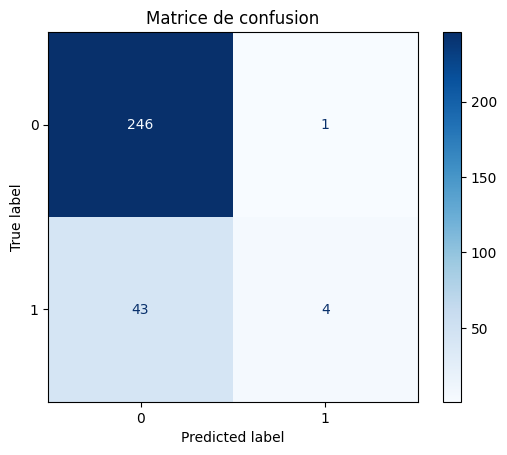

 --- Matrix Key ---
  _________
 | TN | FP |
 | FN | TP |
  ---------


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ___ Calcul de matrice
cm = confusion_matrix(y_test, y_pred)       # ordre à respecter : Realite --> Prediction
print(f"Matrice brute : \n {cm}")

# ___ Affichage Visuel
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_instance.classes_)

# ___ Dessiner graphique
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion")
plt.show()

# ___ Interpretation de la matrice
print(" --- Matrix Key ---")
print("  _________")
print(" | TN | FP |")
print(" | FN | TP |")
print("  ---------")

### Courbe ROC

In [ ]:
from sklearn.metrics import roc_curve, auc

# --- Sauvegarder l'ordre officiel lors de l'entrainement
cols_officielles = X_train.columns.tolist() 
joblib.dump(cols_officielles, "../../models/colonnes_officielles.pkl")
print("--- Liste de colonnes sauvegardees ---")
# --- Charger l'ordre officiel
cols_officielles = joblib.load("../../models/colonnes_officielles.pkl")

# --- FORCER l'ordre (l'etape magique)
df_final = df_final[cols_officielles]       # les colonnes dans le bon ordre : planter s'il en manque une  

# --- standarisation
scaler_var=joblib.load("../../models/scaler_attrition.pkl")
df_final_scaled=scaler_var.transform(df_final)

# --- prédire sans peur
pred = model_instance.predict(df_final_scaled)
print(f"pred : {pred}")

--- Liste de colonnes sauvegardees ---
pred : [0 0 0 ... 0 0 0]


### GridSearch CV

In [ ]:
from sklearn.model_selection import GridSearchCV

print("--- Démarrage de l'optimisation du Random Forest... ---")

# --- le modèle de base et la grille
rf = RandomForestClassifier(random_state=100)
param_grid = {
    'n_estimators': [50, 100, 200],       # Nombre d'arbres
    'max_depth': [None, 10, 20, 30],      # Profondeur
    'min_samples_leaf': [1, 2, 4],        # eviter overfitting
    'criterion': ['gini', 'entropy']      # Méthode de calcul
}

# --- Lancer la recherche : GridSearchCV
# n_jobs=-1  : toute la puissance de machine sera utilisee
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=3,
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

# --- selectif : Récupérer le "champion"
best_rf_model = grid_search.best_estimator_

print(f" -> Meilleurs paramètres : {grid_search.best_params_}")
print(f" -> Meilleur score sur train : {grid_search.best_score_:.2%}")

--- Démarrage de l'optimisation du Random Forest... ---
Fitting 3 folds for each of 72 candidates, totalling 216 fits
 -> Meilleurs paramètres : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 50}
 -> Meilleur score sur train : 84.35%
